In [1]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.shape

(541909, 8)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [5]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [6]:
df.duplicated().sum()

np.int64(5268)

In [7]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(9288)

In [9]:
(df['Quantity'] < 0).sum()

np.int64(10624)

In [10]:
df['Quantity'].describe()

,Quantity
count,541909.000000
mean,9.552250
std,218.081158
min,-80995.000000
25%,1.000000
50%,3.000000
75%,10.000000
max,80995.000000


In [11]:
df['UnitPrice'].describe()

,UnitPrice
count,541909.000000
mean,4.611114
std,96.759853
min,-11062.060000
25%,1.250000
50%,2.080000
75%,4.130000
max,38970.000000


In [12]:
(df['UnitPrice'] <= 0).sum()

np.int64(2517)

In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [14]:
print("Starting Date:", df['InvoiceDate'].min())
print("Ending Date:", df['InvoiceDate'].max())

Starting Date: 2010-12-01 08:26:00
Ending Date: 2011-12-09 12:50:00


In [15]:
clean_df = df.copy()

In [16]:
clean_df = clean_df.dropna(subset=['CustomerID'])

In [17]:
clean_df = clean_df.drop_duplicates()

In [18]:
clean_df = clean_df[~clean_df['InvoiceNo'].astype(str).str.startswith('C')]

In [19]:
clean_df = clean_df[clean_df['Quantity'] > 0]

In [20]:
clean_df = clean_df[clean_df['UnitPrice'] > 0]

In [21]:
print("Original shape:", df.shape)
print("Cleaned shape:", clean_df.shape)

Original shape: (541909, 8)
Cleaned shape: (392692, 8)


In [22]:
clean_df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [23]:
clean_df.duplicated().sum()

np.int64(0)

In [24]:
clean_df['TransactionValue'] = (
    clean_df['Quantity'] * clean_df['UnitPrice']
)

In [25]:
clean_df[['Quantity', 'UnitPrice', 'TransactionValue']].head()

,Quantity,UnitPrice,TransactionValue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [26]:
clean_df[['Quantity', 'UnitPrice', 'TransactionValue']].head()

,Quantity,UnitPrice,TransactionValue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [28]:
clean_df['InvoiceDate'] = pd.to_datetime(clean_df['InvoiceDate'])

print(clean_df['InvoiceDate'].dtype)

datetime64[ns]


In [29]:
reference_date = clean_df['InvoiceDate'].max()

print(reference_date)

2011-12-09 12:50:00


In [30]:
recency = clean_df.groupby('CustomerID')['InvoiceDate'].max().reset_index()

recency['Recency'] = (
    reference_date - recency['InvoiceDate']
).dt.days

recency = recency[['CustomerID', 'Recency']]

recency.head()

,CustomerID,Recency
0,12346.0,325
1,12347.0,1
2,12348.0,74
3,12349.0,18
4,12350.0,309


In [31]:
frequency = clean_df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

frequency.columns = ['CustomerID', 'Frequency']

frequency.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [32]:
monetary = clean_df.groupby('CustomerID')['TransactionValue'].sum().reset_index()

monetary.columns = ['CustomerID', 'Monetary']

monetary.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [33]:
avg_order_value = (
    clean_df.groupby('CustomerID')['TransactionValue']
    .sum()
    /
    clean_df.groupby('CustomerID')['InvoiceNo'].nunique()
).reset_index()

avg_order_value.columns = ['CustomerID', 'AvgOrderValue']

avg_order_value.head()

,CustomerID,AvgOrderValue
0,12346.0,77183.600000
1,12347.0,615.714286
2,12348.0,449.310000
3,12349.0,1757.550000
4,12350.0,334.400000


In [34]:
total_quantity = clean_df.groupby('CustomerID')['Quantity'].sum().reset_index()

total_quantity.columns = ['CustomerID', 'TotalQuantity']

total_quantity.head()

,CustomerID,TotalQuantity
0,12346.0,74215
1,12347.0,2458
2,12348.0,2341
3,12349.0,631
4,12350.0,197


In [35]:
unique_products = clean_df.groupby('CustomerID')['StockCode'].nunique().reset_index()

unique_products.columns = ['CustomerID', 'UniqueProducts']

unique_products.head()

,CustomerID,UniqueProducts
0,12346.0,1
1,12347.0,103
2,12348.0,22
3,12349.0,73
4,12350.0,17


In [36]:
customer_df = recency.merge(
    frequency, on='CustomerID'
).merge(
    monetary, on='CustomerID'
).merge(
    avg_order_value, on='CustomerID'
).merge(
    total_quantity, on='CustomerID'
).merge(
    unique_products, on='CustomerID'
)

In [37]:
customer_df.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts
0,12346.0,325,1,77183.60,77183.600000,74215,1
1,12347.0,1,7,4310.00,615.714286,2458,103
2,12348.0,74,4,1797.24,449.310000,2341,22
3,12349.0,18,1,1757.55,1757.550000,631,73
4,12350.0,309,1,334.40,334.400000,197,17


In [38]:
customer_df.shape

(4338, 7)

In [39]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      4338 non-null   float64
 1   Recency         4338 non-null   int64  
 2   Frequency       4338 non-null   int64  
 3   Monetary        4338 non-null   float64
 4   AvgOrderValue   4338 non-null   float64
 5   TotalQuantity   4338 non-null   int64  
 6   UniqueProducts  4338 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 237.4 KB


##ML_Part


In [40]:
print("Start:", clean_df['InvoiceDate'].min())
print("End:", clean_df['InvoiceDate'].max())

Start: 2010-12-01 08:26:00
End: 2011-12-09 12:50:00


In [41]:
cutoff_date = clean_df['InvoiceDate'].min() + pd.Timedelta(days=270)

print("Cutoff Date:", cutoff_date)

Cutoff Date: 2011-08-28 08:26:00


In [42]:
historical_df = clean_df[
    clean_df['InvoiceDate'] <= cutoff_date
].copy()

print(historical_df.shape)

(221745, 9)


In [43]:
future_df = clean_df[
    clean_df['InvoiceDate'] > cutoff_date
].copy()

print(future_df.shape)

(170947, 9)


In [44]:
future_customers = future_df['CustomerID'].unique()

In [45]:
customer_df['RepeatPurchase'] = customer_df['CustomerID'].isin(
    future_customers
).astype(int)

In [46]:
customer_df['RepeatPurchase'].value_counts()

,count
RepeatPurchase,
1,2996
0,1342


In [47]:
customer_df['RepeatPurchase'].value_counts(normalize=True) * 100

,proportion
RepeatPurchase,
1,69.064085
0,30.935915


In [48]:
cutoff_date = clean_df['InvoiceDate'].min() + pd.Timedelta(days=270)

historical_df = clean_df[
    clean_df['InvoiceDate'] <= cutoff_date
].copy()

future_df = clean_df[
    clean_df['InvoiceDate'] > cutoff_date
].copy()

print("Historical:", historical_df.shape)
print("Future:", future_df.shape)

Historical: (221745, 9)
Future: (170947, 9)


In [49]:
# Customer Features from Historical Data
historical_df['TransactionValue'] = (
    historical_df['Quantity'] * historical_df['UnitPrice']
)

In [50]:
reference_date = historical_df['InvoiceDate'].max()

recency = (
    historical_df.groupby('CustomerID')['InvoiceDate']
    .max()
    .reset_index()
)

recency['Recency'] = (
    reference_date - recency['InvoiceDate']
).dt.days

recency = recency[['CustomerID', 'Recency']]

In [51]:
frequency = (
    historical_df.groupby('CustomerID')['InvoiceNo']
    .nunique()
    .reset_index()
)

frequency.columns = ['CustomerID', 'Frequency']

In [52]:
monetary = (
    historical_df.groupby('CustomerID')['TransactionValue']
    .sum()
    .reset_index()
)

monetary.columns = ['CustomerID', 'Monetary']

In [53]:
avg_order_value = (
    historical_df.groupby('CustomerID')['TransactionValue'].sum()
    /
    historical_df.groupby('CustomerID')['InvoiceNo'].nunique()
).reset_index()

avg_order_value.columns = ['CustomerID', 'AvgOrderValue']

In [54]:
total_quantity = (
    historical_df.groupby('CustomerID')['Quantity']
    .sum()
    .reset_index()
)

total_quantity.columns = ['CustomerID', 'TotalQuantity']

In [55]:
unique_products = (
    historical_df.groupby('CustomerID')['StockCode']
    .nunique()
    .reset_index()
)

unique_products.columns = ['CustomerID', 'UniqueProducts']

In [56]:
customer_features = recency.merge(
    frequency, on='CustomerID'
).merge(
    monetary, on='CustomerID'
).merge(
    avg_order_value, on='CustomerID'
).merge(
    total_quantity, on='CustomerID'
).merge(
    unique_products, on='CustomerID'
)

In [57]:
customer_features.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts
0,12346.0,220,1,77183.60,77183.600000,74215,1
1,12347.0,24,5,2790.86,558.172000,1590,82
2,12348.0,143,3,1487.24,495.746667,2124,22
3,12350.0,204,1,334.40,334.400000,197,17
4,12352.0,156,5,1561.81,312.362000,254,26


In [58]:
customer_features.shape

(3305, 7)

In [59]:
customer_features['RepeatPurchase'] = (
    customer_features['CustomerID']
    .isin(future_customers)
    .astype(int)
)

In [60]:
customer_features.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts,RepeatPurchase
0,12346.0,220,1,77183.60,77183.600000,74215,1,0
1,12347.0,24,5,2790.86,558.172000,1590,82,1
2,12348.0,143,3,1487.24,495.746667,2124,22,1
3,12350.0,204,1,334.40,334.400000,197,17,0
4,12352.0,156,5,1561.81,312.362000,254,26,1


In [61]:
customer_features['RepeatPurchase'].value_counts()

,count
RepeatPurchase,
1,1963
0,1342


In [62]:
customer_features['RepeatPurchase'].value_counts()

,count
RepeatPurchase,
1,1963
0,1342


In [63]:
customer_features['RepeatPurchase'].value_counts(normalize=True) * 100

,proportion
RepeatPurchase,
1,59.394856
0,40.605144


In [64]:
model_df = customer_features.drop(columns=['CustomerID'])

In [65]:
model_df.head()

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts,RepeatPurchase
0,220,1,77183.60,77183.600000,74215,1,0
1,24,5,2790.86,558.172000,1590,82,1
2,143,3,1487.24,495.746667,2124,22,1
3,204,1,334.40,334.400000,197,17,0
4,156,5,1561.81,312.362000,254,26,1


In [66]:
model_df.shape

(3305, 7)

In [67]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3305 entries, 0 to 3304
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Recency         3305 non-null   int64  
 1   Frequency       3305 non-null   int64  
 2   Monetary        3305 non-null   float64
 3   AvgOrderValue   3305 non-null   float64
 4   TotalQuantity   3305 non-null   int64  
 5   UniqueProducts  3305 non-null   int64  
 6   RepeatPurchase  3305 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 180.9 KB


In [68]:
model_df.head()
model_df.shape
model_df['RepeatPurchase'].value_counts()

,count
RepeatPurchase,
1,1963
0,1342


##EDA


In [69]:
# Exploratory Data Analysis

import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
model_df['RepeatPurchase'].value_counts()

,count
RepeatPurchase,
1,1963
0,1342


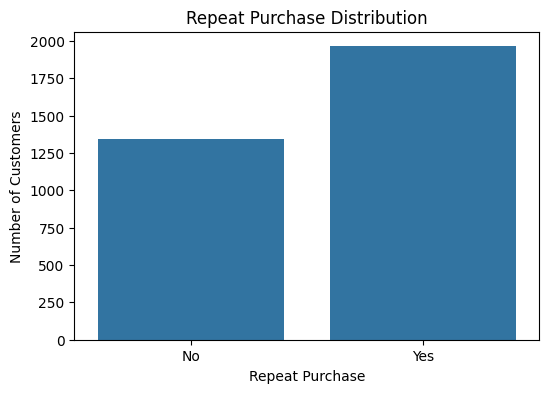

In [71]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='RepeatPurchase',
    data=model_df
)

plt.title('Repeat Purchase Distribution')
plt.xlabel('Repeat Purchase')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['No', 'Yes'])

plt.show()

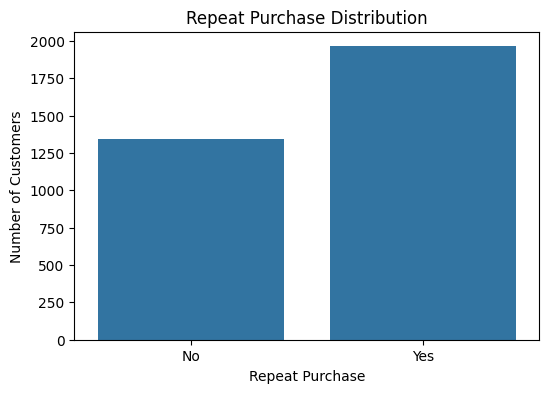

In [72]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='RepeatPurchase',
    data=model_df
)

plt.title('Repeat Purchase Distribution')
plt.xlabel('Repeat Purchase')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['No', 'Yes'])

plt.show()

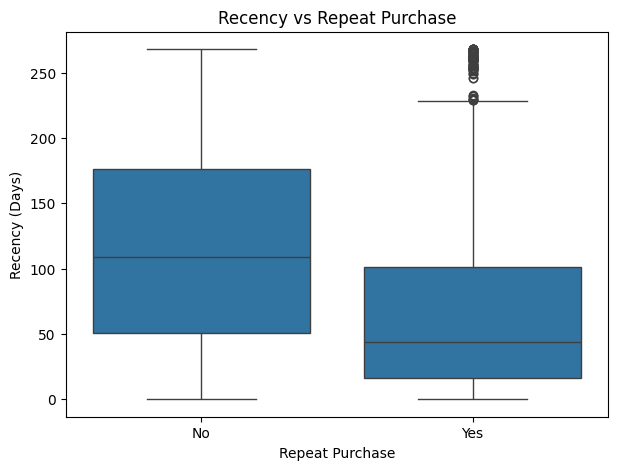

In [73]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='RepeatPurchase',
    y='Recency',
    data=model_df
)

plt.title('Recency vs Repeat Purchase')
plt.xlabel('Repeat Purchase')
plt.ylabel('Recency (Days)')
plt.xticks([0, 1], ['No', 'Yes'])

plt.show()

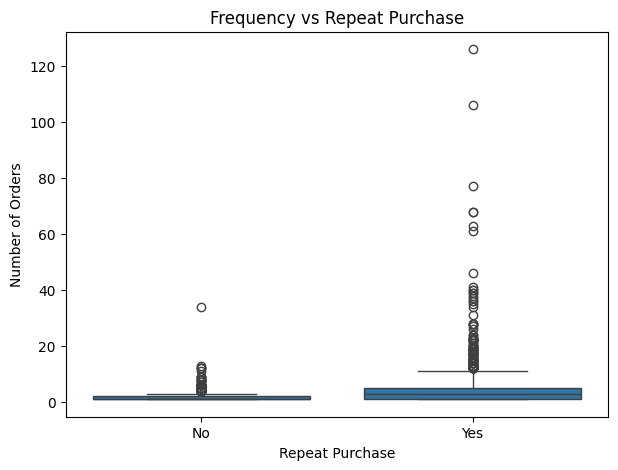

In [74]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='RepeatPurchase',
    y='Frequency',
    data=model_df
)

plt.title('Frequency vs Repeat Purchase')
plt.xlabel('Repeat Purchase')
plt.ylabel('Number of Orders')
plt.xticks([0, 1], ['No', 'Yes'])

plt.show()

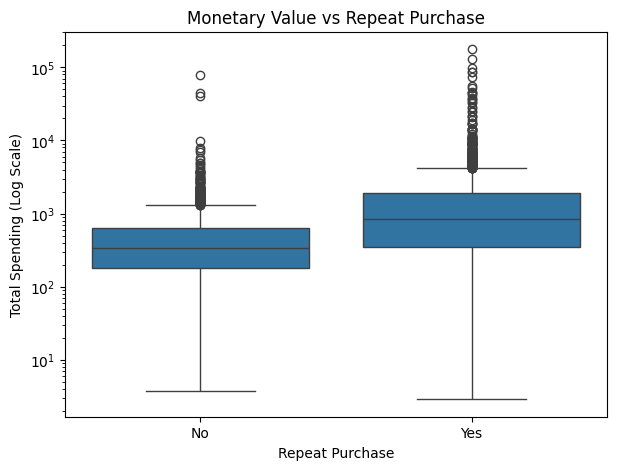

In [75]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='RepeatPurchase',
    y='Monetary',
    data=model_df
)

plt.yscale('log')

plt.title('Monetary Value vs Repeat Purchase')
plt.xlabel('Repeat Purchase')
plt.ylabel('Total Spending (Log Scale)')
plt.xticks([0, 1], ['No', 'Yes'])

plt.show()

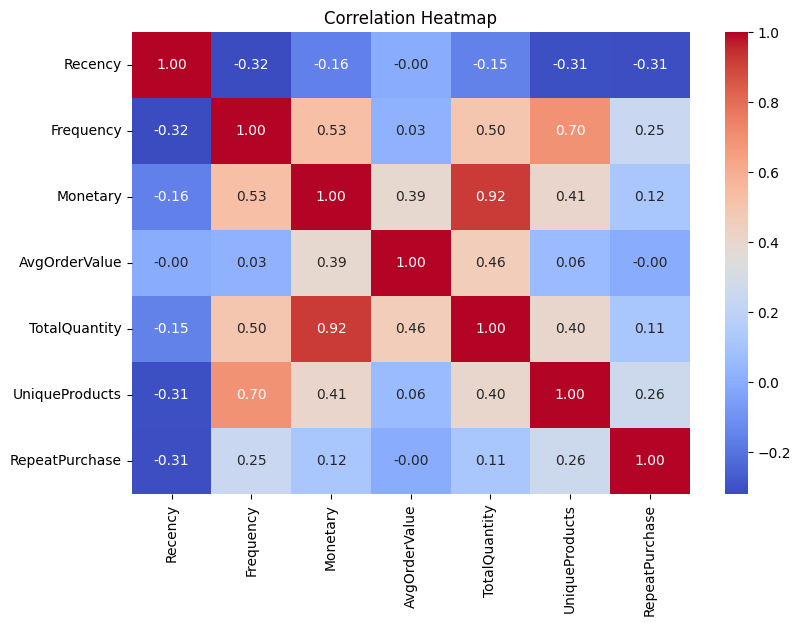

In [76]:
plt.figure(figsize=(9,6))

sns.heatmap(
    model_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

##Machine Learning Model


In [78]:
X = model_df.drop(columns=['RepeatPurchase'])
y = model_df['RepeatPurchase']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3305, 6)
y shape: (3305,)


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2644, 6)
Testing data: (661, 6)


In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2644, 6)
Testing data: (661, 6)


In [82]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [83]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [85]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Model trained successfully!")

Model trained successfully!


In [86]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Model trained successfully!")

Model trained successfully!


In [87]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[168 100]
 [104 289]]


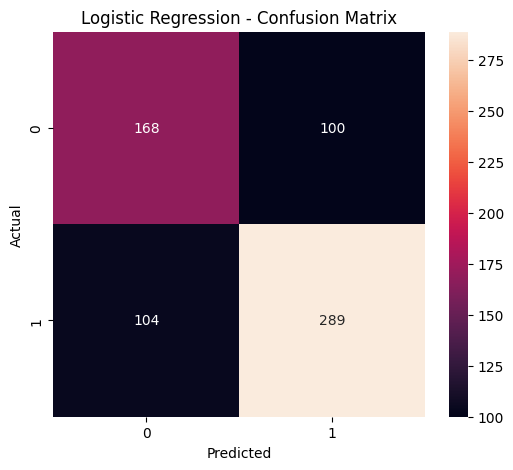

In [88]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [90]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [92]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.6475037821482602
Precision: 0.7010050251256281
Recall: 0.7099236641221374
F1 Score: 0.7054361567635904

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.56      0.56       268
           1       0.70      0.71      0.71       393

    accuracy                           0.65       661
   macro avg       0.63      0.63      0.63       661
weighted avg       0.65      0.65      0.65       661



In [93]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[149 119]
 [114 279]]


In [94]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[149 119]
 [114 279]]


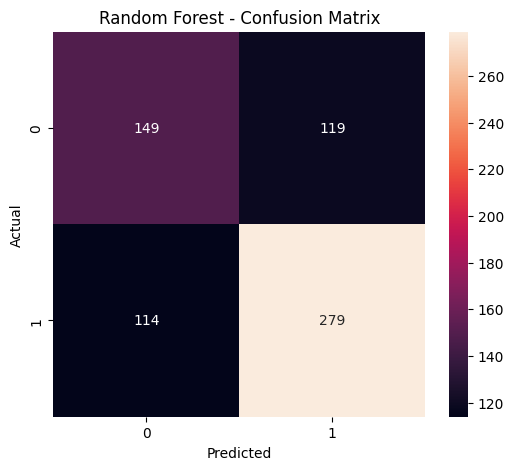

In [95]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d'
)

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [96]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.691377,0.742931,0.735369,0.739130
1,Random Forest,0.647504,0.701005,0.709924,0.705436


In [98]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
4,TotalQuantity,0.204947
2,Monetary,0.194961
0,Recency,0.186234
3,AvgOrderValue,0.166956
5,UniqueProducts,0.155356
1,Frequency,0.091546


In [99]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
4,TotalQuantity,0.204947
2,Monetary,0.194961
0,Recency,0.186234
3,AvgOrderValue,0.166956
5,UniqueProducts,0.155356
1,Frequency,0.091546


In [100]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.691377,0.742931,0.735369,0.739130
1,Random Forest,0.647504,0.701005,0.709924,0.705436


In [101]:
import joblib

final_model = rf_model

joblib.dump(final_model, 'retail_purchase_model.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print("Final model saved successfully!")

Final model saved successfully!


In [102]:
import os

print("Model:", os.path.exists('retail_purchase_model.pkl'))
print("Features:", os.path.exists('feature_names.pkl'))

Model: True
Features: True


In [103]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.691377,0.742931,0.735369,0.739130
1,Random Forest,0.647504,0.701005,0.709924,0.705436


In [104]:
print("Best model based on your selected business metric:")
print(results)

Best model based on your selected business metric:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.691377   0.742931  0.735369  0.739130
1        Random Forest  0.647504   0.701005  0.709924  0.705436


In [105]:
from google.colab import files

files.download('retail_purchase_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [106]:
files.download('feature_names.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [109]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [111]:
import joblib

joblib.dump(logistic_model, 'logistic_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print("Files saved successfully!")

Files saved successfully!


In [112]:
import os

print("Model:", os.path.exists('logistic_regression_model.pkl'))
print("Scaler:", os.path.exists('scaler.pkl'))
print("Features:", os.path.exists('feature_names.pkl'))

Model: True
Scaler: True
Features: True


In [114]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 26.5 MB/s eta 0:00:00


In [155]:
%%writefile app.py

import streamlit as st
import joblib
import pandas as pd

# Load model files
model = joblib.load("logistic_regression_model.pkl")
scaler = joblib.load("scaler.pkl")
feature_names = joblib.load("feature_names.pkl")

# Load dataset
df = pd.read_excel("Online Retail.xlsx")

# Data cleaning
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df = df.dropna(subset=["CustomerID"])
df = df.drop_duplicates()
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df["TransactionValue"] = df["Quantity"] * df["UnitPrice"]

# Historical and future data
cutoff_date = df["InvoiceDate"].min() + pd.Timedelta(days=270)

historical_df = df[df["InvoiceDate"] <= cutoff_date].copy()
future_df = df[df["InvoiceDate"] > cutoff_date].copy()

future_customers = future_df["CustomerID"].unique()

# Customer features
reference_date = historical_df["InvoiceDate"].max()

customer_features = historical_df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TransactionValue", "sum"),
    TotalQuantity=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique")
).reset_index()

customer_features["AvgOrderValue"] = (
    customer_features["Monetary"] /
    customer_features["Frequency"]
)

customer_features["RepeatPurchase"] = (
    customer_features["CustomerID"]
    .isin(future_customers)
    .astype(int)
)

# Page settings
st.set_page_config(
    page_title="Retail Purchase Prediction",
    layout="wide"
)

st.title("Retail Customer Repeat Purchase Prediction")

# Navigation
page = st.sidebar.radio(
    "Select Page",
    ["Business Problem", "Data Insights", "Prediction"]
)

# PAGE 1
if page == "Business Problem":

    st.header("Business Problem")

    st.write(
        "The objective is to predict whether an existing retail "
        "customer is likely to make a repeat purchase based on "
        "their historical purchasing behaviour."
    )

# PAGE 2
elif page == "Data Insights":

    st.header("Data Insights")

    st.subheader("Repeat Purchase Distribution")

    purchase_counts = (
        customer_features["RepeatPurchase"]
        .value_counts()
        .rename(
            index={
                0: "No Repeat Purchase",
                1: "Repeat Purchase"
            }
        )
    )

    st.bar_chart(purchase_counts)

# PAGE 3
elif page == "Prediction":

    st.header("Customer Repeat Purchase Prediction")

    recency = st.number_input(
        "Recency (days)",
        min_value=0.0,
        value=30.0
    )

    frequency = st.number_input(
        "Frequency (number of orders)",
        min_value=1.0,
        value=5.0
    )

    monetary = st.number_input(
        "Monetary (total spending)",
        min_value=0.0,
        value=500.0
    )

    avg_order = st.number_input(
        "Average Order Value",
        min_value=0.0,
        value=100.0
    )

    total_quantity = st.number_input(
        "Total Quantity",
        min_value=1.0,
        value=20.0
    )

    unique_products = st.number_input(
        "Unique Products",
        min_value=1.0,
        value=10.0
    )

    predict_button = st.button("Predict")

    if predict_button:

        input_data = pd.DataFrame(
            [[
                recency,
                frequency,
                monetary,
                avg_order,
                total_quantity,
                unique_products
            ]],
            columns=feature_names
        )

        input_scaled = scaler.transform(input_data)

        prediction = model.predict(input_scaled)[0]
        probability = model.predict_proba(input_scaled)[0][1]

        if prediction == 1:
            st.success("Prediction: Repeat Purchase")
        else:
            st.warning("Prediction: No Repeat Purchase")

        st.write(
            f"Probability of Repeat Purchase: {probability:.2%}"
        )

Overwriting app.py


In [172]:
%%writefile app.py

Overwriting app.py


In [173]:
import os
print(os.path.exists("app.py"))

True


In [174]:
!streamlit run app.py --server.port 8512 --server.address 0.0.0.0 > streamlit.log 2>&1 &

In [175]:
!cat streamlit.log



2026-09-13 12:29:22.695 Uvicorn server started on 0.0.0.0:8512

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8512
  Network URL: http://172.28.0.12:8512
  External URL: http://104.196.248.203:8512



In [176]:
!curl -m 5 -I http://localhost:8512

HTTP/1.1 200 OK
date: Sun, 13 Sep 2026 12:29:40 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 7459
last-modified: Sun, 13 Sep 2026 10:24:25 GMT
etag: "d0122506b8c0c34858c1d386d25f43d9"
cache-control: no-cache



In [177]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
changed 22 packages in 3s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼

In [182]:
!lt --port 8512

your url is: https://mighty-women-bake.loca.lt
^C


In [183]:

!cat streamlit.log



2026-09-13 12:29:22.695 Uvicorn server started on 0.0.0.0:8512

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8512
  Network URL: http://172.28.0.12:8512
  External URL: http://104.196.248.203:8512

  Stopping...


In [184]:
!curl -m 10 http://localhost:8512

curl: (7) Failed to connect to localhost port 8512 after 0 ms: Couldn't connect to server


In [185]:
!ps aux | grep streamlit

root       52954  0.0  0.0   7340  3612 ?        S    12:47   0:00 /bin/bash -c ps aux | grep streamlit
root       52956  0.0  0.0   6544  2380 ?        S    12:47   0:00 grep streamlit


In [186]:
import os

for f in [
    "app.py",
    "MLBA_CIA2.ipynb",
    "Online Retail.xlsx",
    "logistic_regression_model.pkl",
    "scaler.pkl",
    "feature_names.pkl",
    "requirements.txt",
    "README.md"
]:
    print(f, "→", os.path.exists(f))

app.py → True
MLBA_CIA2.ipynb → False
Online Retail.xlsx → True
logistic_regression_model.pkl → True
scaler.pkl → True
feature_names.pkl → True
requirements.txt → False
README.md → False
